In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'

#*************************** choose variable,factor and path


variable2 = 'shelfmelt'
factor = -1* 365.25 * 24 * 3600/900
pth = pth_helene


variable = 'iareafl'




variable3 = 'thermalforcing'
pth3 = pth_imip6hack
# variable2 = 'iareafl'
# factor = 1
# pth = pth_helene

# variable2 = 'iareagr'
# factor = 1
# pth = pth_helene


# variable2 = 'dslc_anom'
# factor = -1
# pth = pth_imip6hack

fpath = f'./figs/recalc_{variable2}_lin_ms/'
fname = f'average_{variable2}_'

In [2]:

 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
df_ms = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_time2100.csv')
df_ms_n = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept_time2100.csv')

In [3]:
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
dic_area_of_interest['WestAntarctica'] = ['_region_1']
dic_area_of_interest['EastAntarctica'] = ['_region_2']
dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['FilchnerRonne'] = ['_sector_5','_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']

                                
# regionnumbers = [2, 5, 6, 9, 11, 16]
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode1']   = lst                             
                                
# regionnumbers = [1, 3, 4, 8, 18]
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode2']   = lst   

# regionnumbers = [ 7, 10, 12, 13, 14, 15,  17] 
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode_rest']   = lst   

In [4]:
df_ms['WestAntarctica'] = df_ms['region_1']
df_ms['EastAntarctica'] = df_ms['region_2']
df_ms['Peninsula'] = df_ms['region_3']
df_ms_n['WestAntarctica'] = df_ms_n['region_1']
df_ms_n['EastAntarctica'] = df_ms_n['region_2']
df_ms_n['Peninsula'] = df_ms_n['region_3']



In [5]:
fpath='./figs/recalc_shelfmelt_lin_ms_time2100/'
fname='recalc_shelfmelt_lin_ms_'

The path './figs/recalc_shelfmelt_lin_ms_time2100/' already exists.


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_25728/3806439656.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f,ax = plt.subplots(df.shape[0]//2,2,figsize=(a4_width, a4_height))


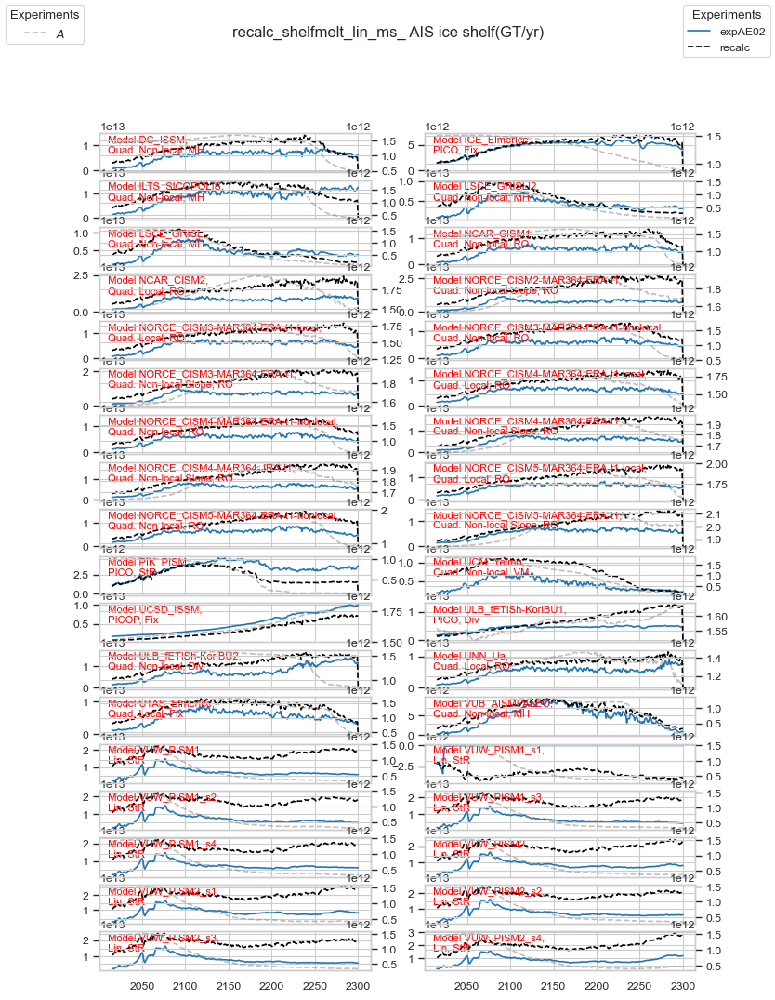

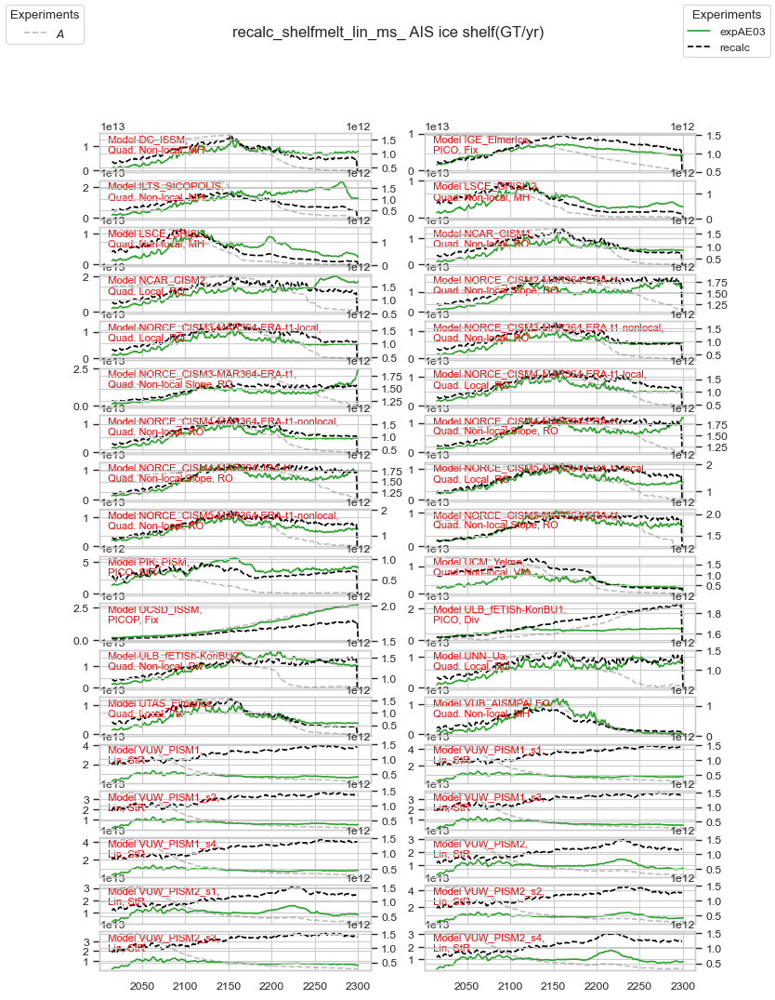

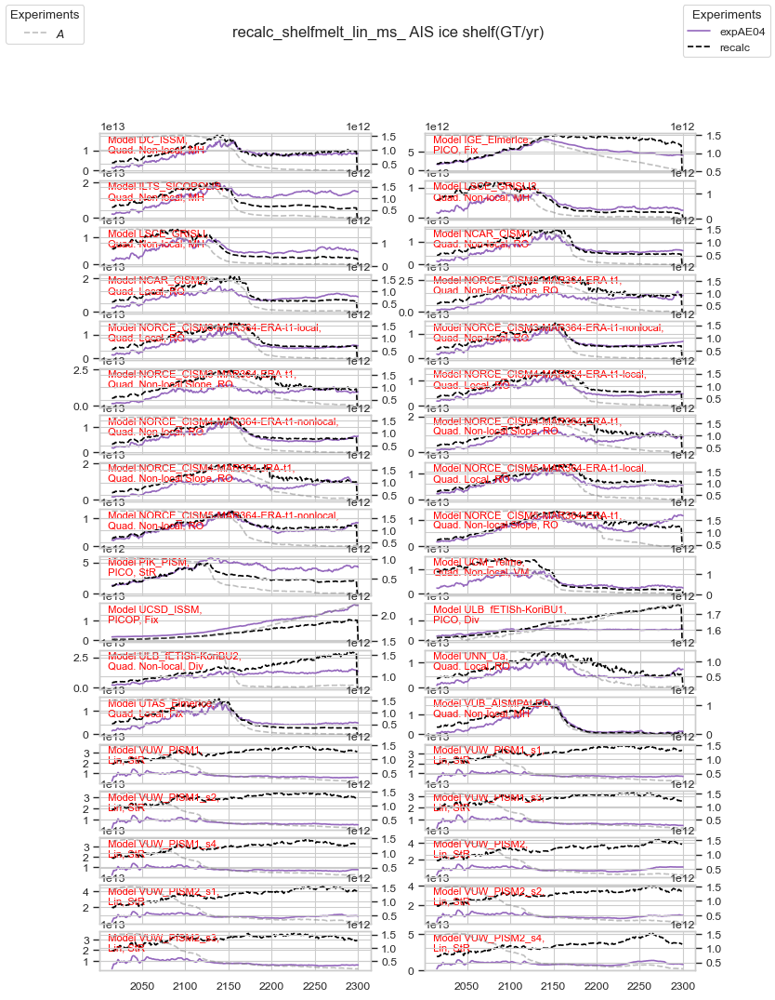

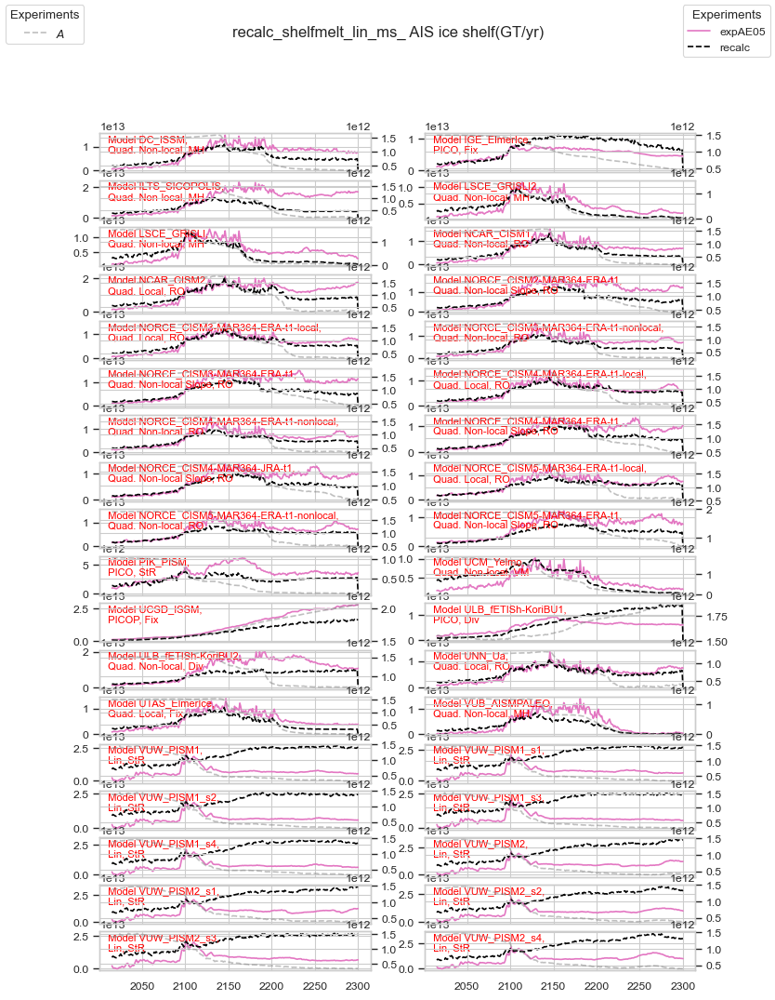

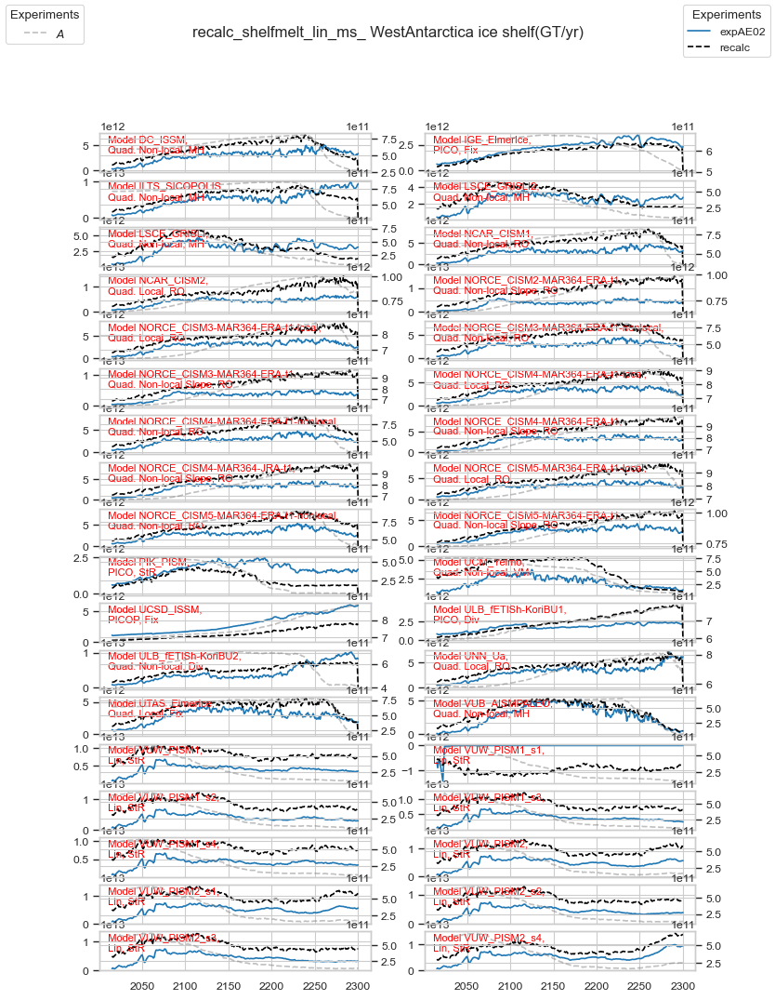

...

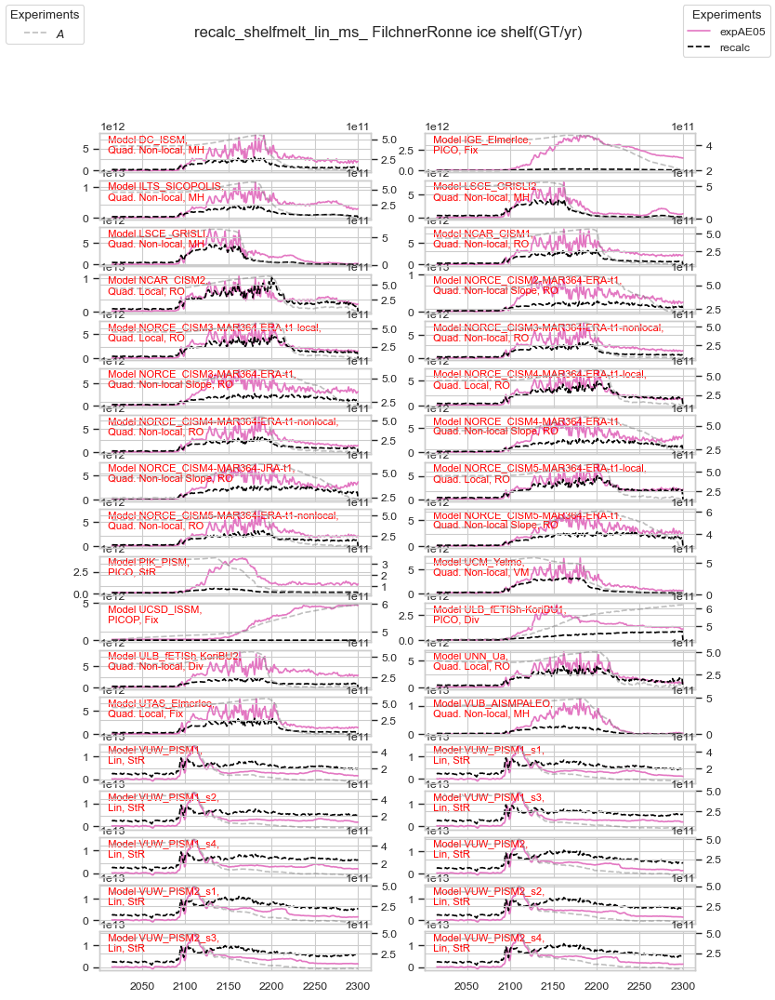

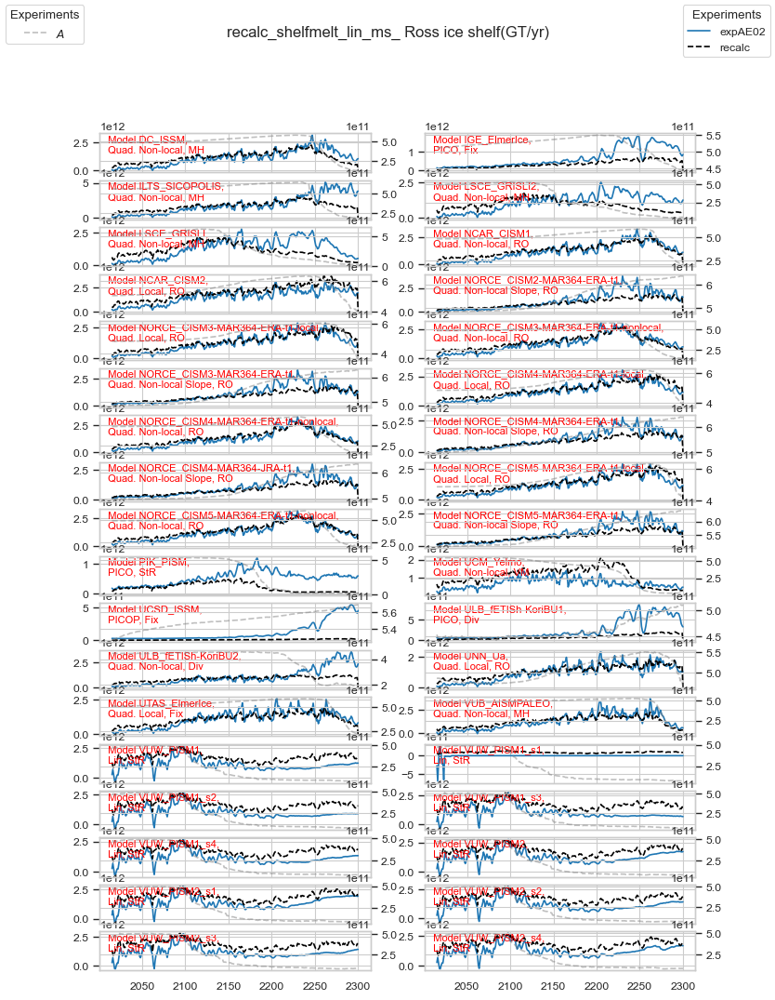

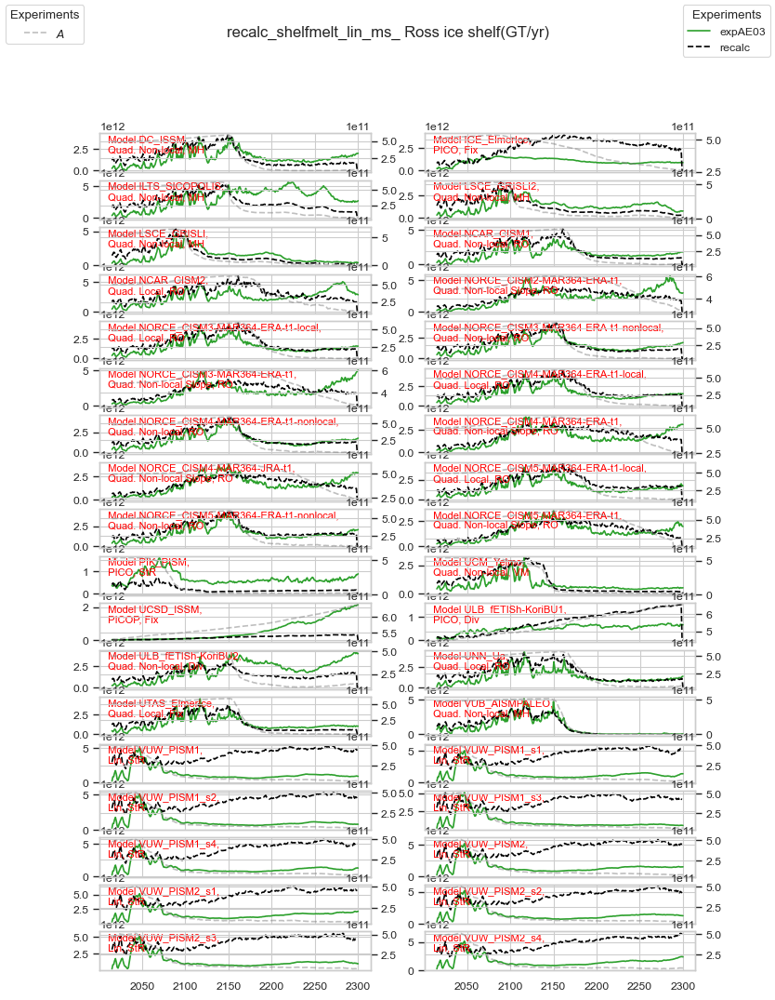

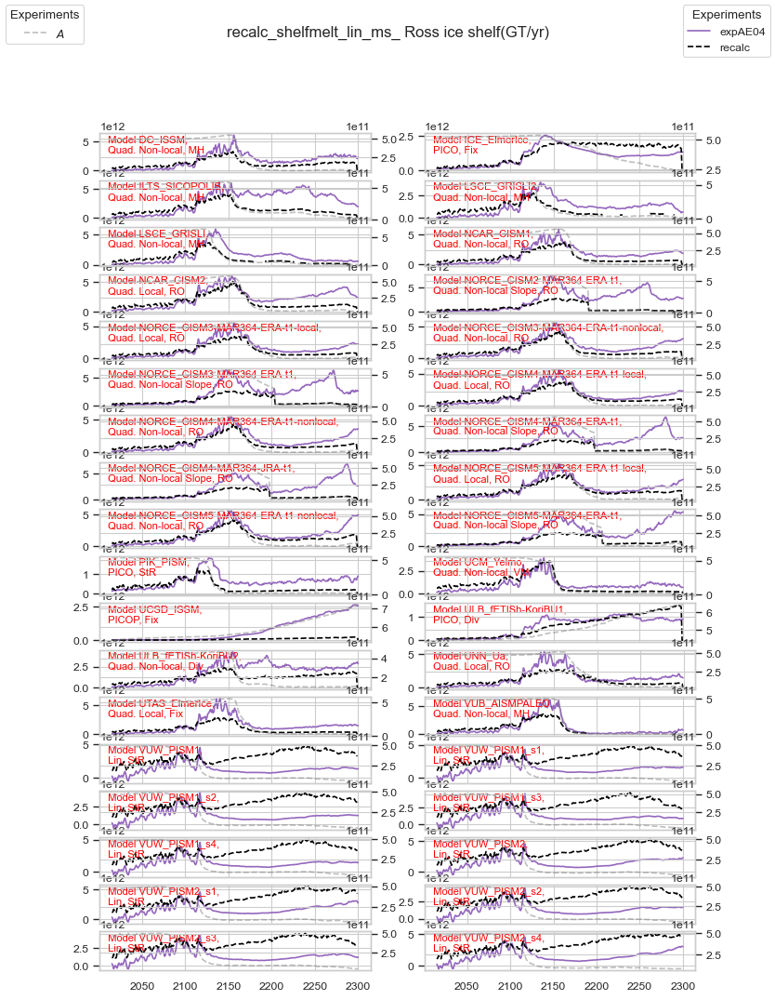

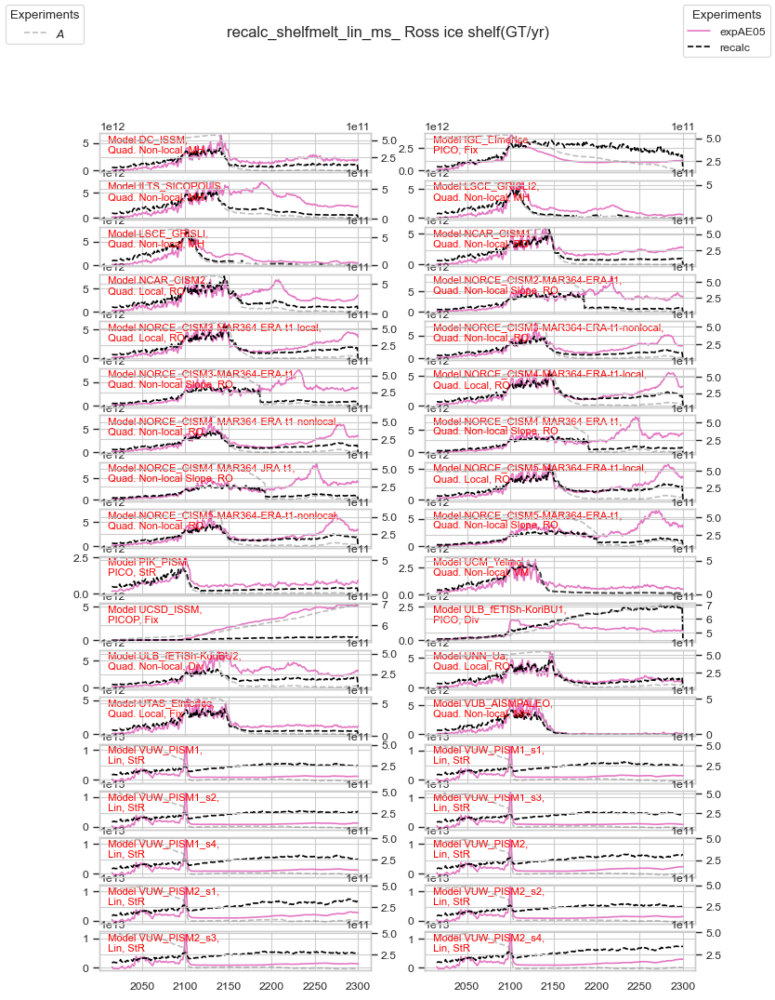

In [6]:
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")
dic_all_err = {}

for key in dic_area_of_interest.keys():
  
    lst = dic_area_of_interest[key]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
    fs = 8

    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    dic_key = {}
    for j,exp in enumerate(expnames):
        dic_exp ={}
        f,ax = plt.subplots(df.shape[0]//2,2,figsize=(a4_width, a4_height))
        
        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        ms_exp =df_ms[df_ms['Experiment']== exp].reset_index(drop=True)
        ms_n_exp =df_ms_n[df_ms_n['Experiment']== exp].reset_index(drop=True)
        

        for i in range (df.shape[0]):
            ix =i //2
            iy=i%2
            pth_way = df.iloc[i].Path
            #get shelf area

            pth_bmb = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

       
            d3 = xr.open_dataset(pth_bmb,decode_times=False )
        
            #get shelf area
            pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/{variable}/computed_{variable}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            d2 = xr.open_dataset(pth_area,decode_times=False )
            #thermal foring 
           
            pth_var3 = f'{pth3}/{df.iloc[i].Experiment}/{variable3}/computed_{variable3}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            
          
           
         
            d4 = xr.open_dataset(pth_var3,decode_times=False )



            
            tmin = np.min([d2.time.size,d3.time.size,d4.time.size])
            #melting per area
            the_ys = np.zeros((len(lst),tmin))
            the_areas = np.zeros((len(lst),tmin))
            the_tfs = np.zeros((len(lst),tmin))
            
            
          
            for k,nm in enumerate(lst):
                the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor
                the_areas[k,:]= d2[f'{variable}{nm}'].values[:tmin]
                the_tfs[k,:]= d4[f'{variable3}{nm}'].values[:tmin]*the_areas[k,:]
                
                

            y = np.sum(the_ys ,axis =0)
            area = np.sum( the_areas,axis = 0)
            TF = np.sum( the_tfs,axis = 0)/area
             
            ms = ms_exp.iloc[i][key]
            ms_n = ms_n_exp.iloc[i][key]
#             print(f'models same{df.iloc[i].Model} and {ms_exp.iloc[i].Model} and {ms_n_exp.iloc[i].Model}')
            
            ax2 = ax[ix,iy]            
            ax3 = ax2.twinx()
#             ax3.plot(d3.time[:tmin],area*TF,color = 'grey',alpha = 0.5,label = '$TF\cdot A$')
            ax3.plot(d3.time[:tmin],area,linestyle = '--',color = 'grey',alpha = 0.5,label = '$ A$')
            
            

            ax2.plot(d3.time[:tmin],y ,color = colors[j],label = f'{exp}')
            ax2.plot(d3.time[:tmin],ms*TF*area +ms_n,color = 'k',linestyle ='dashed',label = f'recalc')
            
           
            
            err = (ms*TF*area +ms_n -y)**2
            msk = np.isnan(err) | (y == 0)
            rmse = (np.sum(err[~msk])/err[~msk].size)**0.5
            prmse = (( (1/err[~msk].size)*np.sum(err[~msk]))/np.sum(y[~msk]**2))**0.5 *100 # %

            dic_exp[df.iloc[i].Model] =prmse.copy()
            df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
            df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
            meltparam =  df_info_model_exp['Melt parameterisation'].values[0]
            icefront =  df_info_model_exp['ice front'].values[0]

            ax2.text(0.02, 0.98,f' Model {df.iloc[i].Model},\n {meltparam}, {icefront} ',transform=ax2.transAxes,fontsize = fs, va='top',color = 'red')
#             ax2.text(0.02, 0.5,f'{np.round(ms,1)}*TF+{np.round(ms_n,1)},',transform=ax2.transAxes,fontsize = fs, va='top',color = 'red')
 #         ax[ix, iy].text(0.02, 0.98, f'Experiment {exp} - Model {df.iloc[i].Model}', transform=ax[ix, iy].transAxes, fontsize=12, va='top')

    #         f.text(0.02, 0.98,
        dic_key[exp]=dic_exp.copy()
        handles, labels = ax[0, 0].get_legend_handles_labels()
        f.legend(handles, labels, loc='upper right', title='Experiments')
        handles, labels = ax3.get_legend_handles_labels()
        f.legend(handles, labels, loc='upper left', title='Experiments')

        f.suptitle(f'{fname} {key} ice shelf(GT/yr)',fontsize = 12)
        f.savefig(f'{fpath}{fname}_{key}_{exp}.pdf')
    dic_all_err[key] = dic_key.copy()

#     for j in range(1,19):

In [7]:
df_err = df_ms.copy()
df_err=df_err.drop(df_err.columns[3:21],axis=1)
df_err=df_err.drop(df_err.columns[4:7],axis=1)
for key in dic_area_of_interest.keys():
    df_err[key]=0

In [8]:
for i in range (df_err.shape[0]):
    model =df_err.iloc[i].Model
    exp =df_err.iloc[i].Experiment
    for j,key in enumerate(dic_area_of_interest.keys()):
        df_err.loc[i,key]= dic_all_err[key][exp][model].copy()
df_err.to_csv('tables/prmse_recalc_linear_meltsensetivity_from_BMB_max_time2100.csv')

In [69]:
i

0

In [76]:
df_err

,Experiment,Model,Path,AIS,Amundsen,Ross,FilchnerRonne,WestAntarctica,EastAntarctica,Peninsula
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,3.534834e+12,7.950326e+10,4.278283e+11,1.620757e+12,1.679478e+12,1.533560e+12,1.929558e+11
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,7.125139e+11,1.487523e+11,4.777300e+11,2.259180e+11,4.146886e+11,6.599373e+11,3.723679e+11
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,3.648334e+12,4.431424e+11,1.077721e+12,1.886475e+12,2.164375e+12,1.378335e+12,1.352489e+11
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,2.015948e+12,2.515669e+10,6.371446e+11,5.871089e+11,9.689994e+11,8.360578e+11,1.221105e+11
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,2.387009e+12,1.913063e+11,7.366392e+11,5.911436e+11,1.366952e+12,8.728465e+11,1.111590e+11
...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,1.451194e+13,3.330024e+11,3.479116e+12,3.518603e+12,3.993556e+12,8.949220e+12,6.337560e+11
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,1.467799e+13,3.697741e+11,3.575661e+12,3.416540e+12,4.045392e+12,9.146564e+12,6.068274e+11
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,1.374921e+13,2.873564e+11,3.303456e+12,3.620067e+12,3.735160e+12,8.399575e+12,6.262286e+11
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,1.403449e+13,3.805147e+11,3.252302e+12,3.325172e+12,4.084402e+12,8.441834e+12,6.317986e+11


In [58]:
dic_area_of_interest.keys()

dict_keys(['AIS', 'WestAntarctica', 'EastAntarctica', 'Peninsula', 'Amundsen', 'FilchnerRonne', 'Ross'])